In [2]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sklearn as sk
from scipy.optimize import minimize
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.base import clone

In [3]:
rodar_rn = False
resetar_banco = False

In [4]:
import os
import glob

# Sua variável de controle

# Caminho da pasta que será limpa
caminho_pasta = r'.\tests_rn\results'

if resetar_banco:
    # Cria uma lista com todos os itens (*) dentro da pasta
    arquivos = glob.glob(os.path.join(caminho_pasta, '*'))
    
    if not arquivos:
        print("A pasta já está vazia.")
    else:
        for arquivo in arquivos:
            try:
                # Garante que vai apagar apenas arquivos, ignorando subpastas caso existam
                if os.path.isfile(arquivo):
                    os.remove(arquivo)
                    print(f"Arquivo apagado: {arquivo}")
            except Exception as e:
                print(f"Erro ao tentar apagar {arquivo}: {e}")
                
        print(f"Limpeza da pasta {caminho_pasta} concluída com sucesso!")

In [5]:
data = [pd.read_csv(r'database\data_occ0_2.csv'),
        pd.read_csv(r'database\data_occ0_5.csv'),
        pd.read_csv(r'database\data_occ0_7.csv'),
        pd.read_csv(r'database\data_occ0_9.csv'),]

phase = [pd.read_csv(r'database\original-database\occupancy_0.2.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.5.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.7.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.9.CSV', index_col = False)['phases'][3:69997]]

for i in range(4):
    data[i]['phases'] = phase[i].values

columns = data[0].columns
occ_name = ['occ0.2', 'occ0.5', 'occ0.7', 'occ0.9']

In [6]:
#Rede Neural
def run_model(X, y, occ):

    # Modelo 
    base_model = MLPRegressor(
        hidden_layer_sizes=(20,10,5),
        activation='tanh',
        solver='adam',
        max_iter=500,
        random_state=42
    )
    

    # Divisão treino e teste (80%/20%)
    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
 
    model = clone(base_model)

    #Treino
    model.fit(X_train, y_train)
    
    # Predições
    y_pred = model.predict(X)

    #Curva de aprendizado 
    plt.figure(figsize=(8,5))
    plt.plot(model.loss_curve_)
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.title(f'Curva de aprendizado - OCC {occ}')
    plt.grid(True)
    plt.show()

    return y_pred


In [7]:
def save_rn(occ, phase, amplitude_data, ns_list):
    path = f'.\\tests_rn\\results\\rn_{occ}.csv'

    if os.path.exists(path):
        df = pd.read_csv(path)
        new_df = pd.DataFrame({                    

            'TruePhase': phase,
            'PhaseEstimada': ns_list,
            'TrueAmplitude': amplitude_data,
        })
        
        df = pd.concat([df, new_df], ignore_index=True)
    else:
        df = pd.DataFrame({
            'TruePhase': phase,
            'PhaseEstimada': ns_list,
            'TrueAmplitude': amplitude_data,
        })

    df.to_csv(f'.\\tests_rn\\results\\rn_{occ}.csv', index=False)

In [8]:
def run_algorithm(data):

    #reset_save() #Limpa os arquivos de resultados antes de rodar o algoritmo
    #Para cada ocupação e cada tolerância, roda o método de Nelder-Mead e salva os resultados
    if rodar_rn:
        k = 0
        for i in range(4):
            samples_data = np.array(data[i][columns[0:7]])
            phases_data = np.array(data[i][columns[8]])
            amplitude_data = np.array(data[i][columns[7]])

            sample4 = run_model(samples_data, phases_data, occ_name[i])
            save_rn(occ_name[i], phases_data, amplitude_data, sample4)
            k +=1
            print(f'Occupancy {occ_name[i][3:]} and tolerance {1} done, lacking {4 - k} combinations')

In [9]:
run_algorithm(data)

In [10]:
def load_results():
    resultados = [
        pd.read_csv(r'.\tests_rn\results\rn_occ0.2.csv'),
        pd.read_csv(r'.\tests_rn\results\rn_occ0.5.csv'),
        pd.read_csv(r'.\tests_rn\results\rn_occ0.7.csv'),
        pd.read_csv(r'.\tests_rn\results\rn_occ0.9.csv'),
    ]
    return resultados

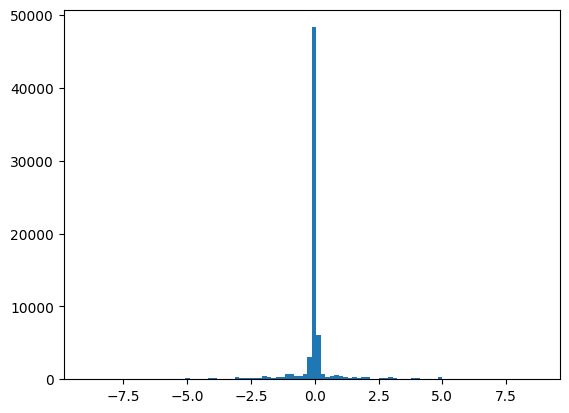

Mean error for occupancy occ0.2: -0.05863480352799556
Std error for occupancy occ0.2: 1.0183560367501006


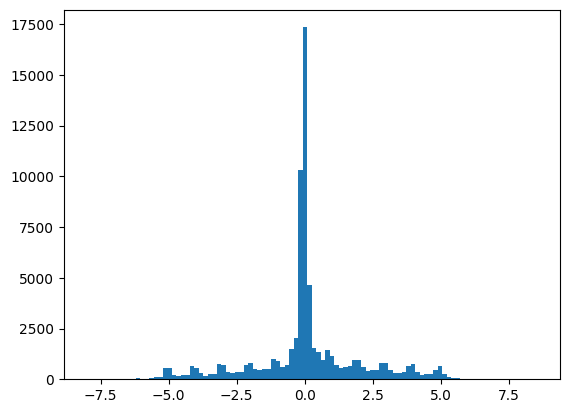

Mean error for occupancy occ0.5: 0.07972777020001719
Std error for occupancy occ0.5: 1.9907651035125395


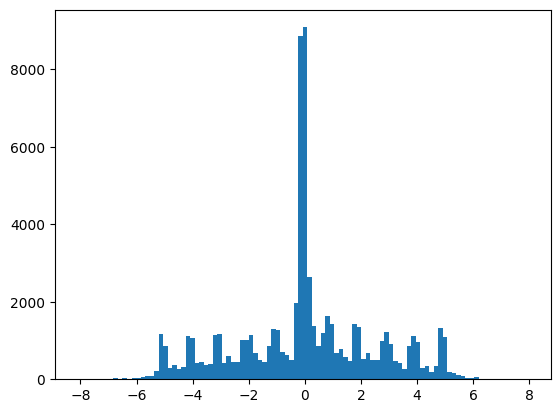

Mean error for occupancy occ0.7: 0.007691803377329034
Std error for occupancy occ0.7: 2.483824107283458


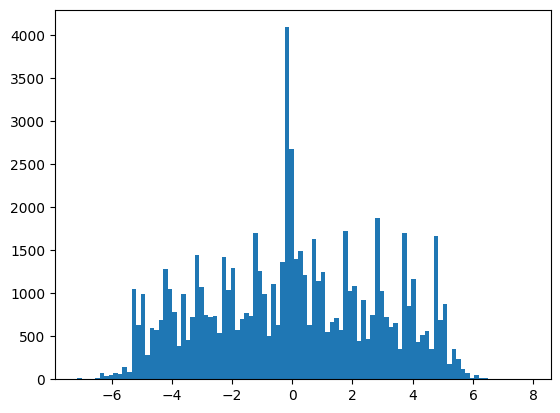

Mean error for occupancy occ0.9: -0.009639939917809296
Std error for occupancy occ0.9: 2.8781841394995107


In [12]:
df = load_results()

for i in range(len(df)):
    phase_error = df[i]['TruePhase'] - df[i]['PhaseEstimada']
    plt.hist(phase_error, bins=100)
    plt.show()
    print(f'Mean error for occupancy {occ_name[i]}: {np.mean(phase_error)}')
    print(f'Std error for occupancy {occ_name[i]}: {np.std(phase_error)}')

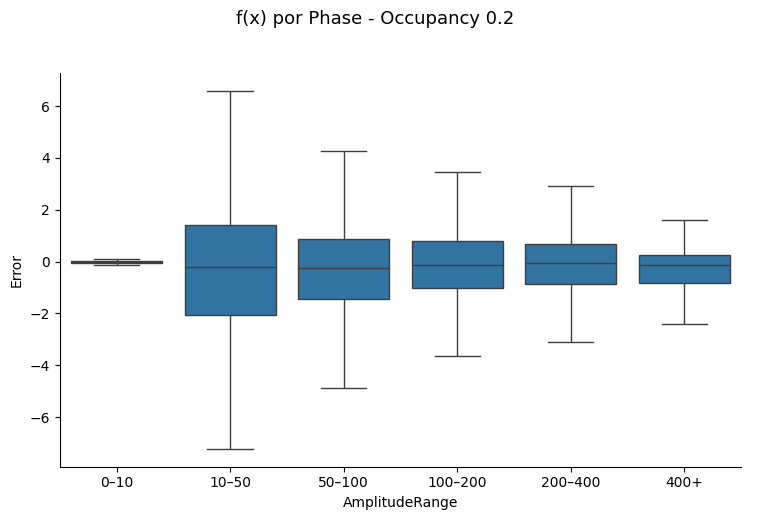

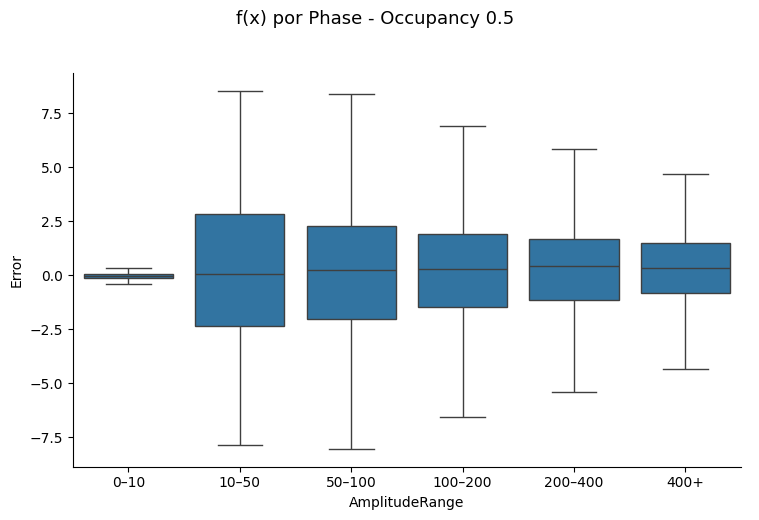

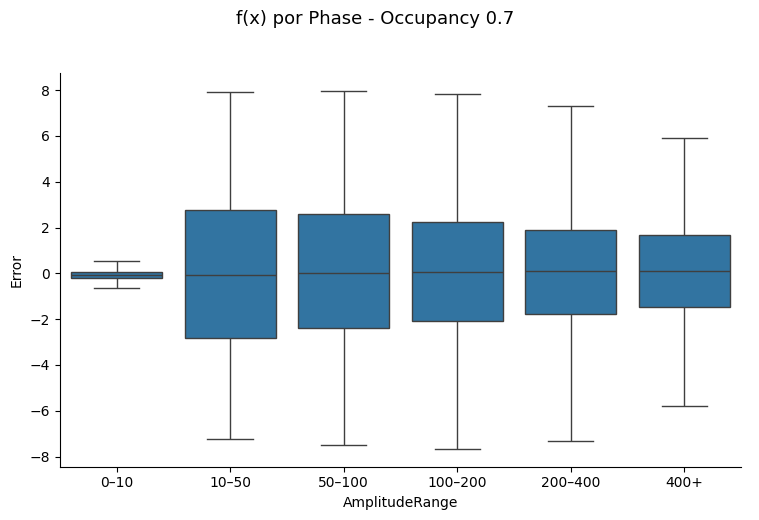

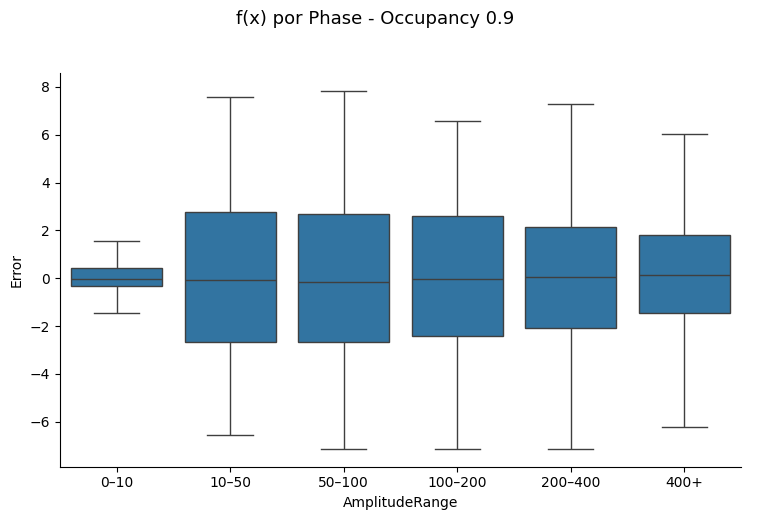

In [15]:
#faixa [0-10, 10-50, 50-100, 100-200, 200-500, 500+]
res = load_results()
bins   = [0, 10, 50, 100, 200, 400, np.inf]
labels = ['0–10', '10–50', '50–100', '100–200', '200–400', '400+']

for i in range(len(df)):
    # Categoriza as amplitudes
    df[i]['AmplitudeRange'] = pd.cut(df[i]['TrueAmplitude'], bins=bins, labels=labels, right=False)
    
    # Cria a coluna de Erro para facilitar o plot
    df[i]['Error'] = df[i]['TruePhase'] - df[i]['PhaseEstimada']

    # plt.figure(figsize=(10, 6)) <-- Você pode remover esta linha

    g = sns.catplot(
        data=df[i],          # <-- CORRIGIDO: Passando o DataFrame da iteração atual
        x='AmplitudeRange',
        y='Error',           # <-- CORRIGIDO: Usando a nova coluna criada
        kind='box',
        height=5,
        aspect=1.5,
        sharey=False,
        showfliers=False
    )

    g.set_axis_labels('AmplitudeRange', 'Error')
    g.set_titles(col_template='E: {col_name}')
    
    g.fig.suptitle(
        f'f(x) por Phase - Occupancy {occ_name[i][3:]}',
        y=1.03, fontsize=13
    )
    
    plt.tight_layout()
    plt.show()